Using: cuda
Epoch 0 Loss: 1.0426
Epoch 1 Loss: 0.7092
Epoch 2 Loss: 0.4991
Epoch 3 Loss: 0.3285
Epoch 4 Loss: 0.2568
Epoch 5 Loss: 0.2151
Epoch 6 Loss: 0.1913
Epoch 7 Loss: 0.1578
Epoch 8 Loss: 0.1627
Epoch 9 Loss: 0.1447
Epoch 10 Loss: 0.1391
Epoch 11 Loss: 0.1127
Epoch 12 Loss: 0.1066
Epoch 13 Loss: 0.0949
Epoch 14 Loss: 0.0820
Epoch 15 Loss: 0.0834
Epoch 16 Loss: 0.1046
Epoch 17 Loss: 0.0818
Epoch 18 Loss: 0.0724
Epoch 19 Loss: 0.0688
Epoch 20 Loss: 0.0661
Epoch 21 Loss: 0.0653
Epoch 22 Loss: 0.0600
Epoch 23 Loss: 0.0587
Epoch 24 Loss: 0.0561
Epoch 25 Loss: 0.0556
Epoch 26 Loss: 0.0777
Epoch 27 Loss: 0.0712
Epoch 28 Loss: 0.0636
Epoch 29 Loss: 0.0757


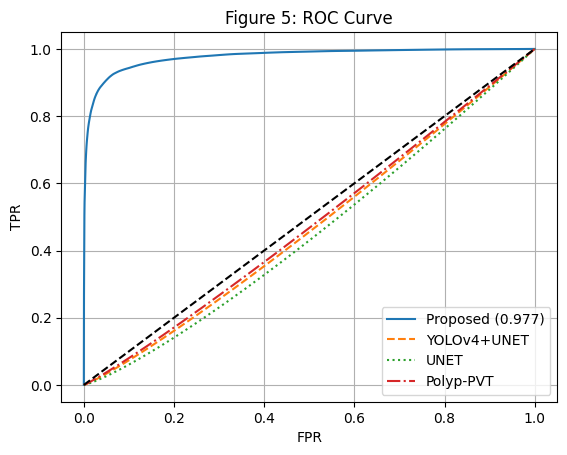

C:\Users\saadi\AppData\Local\Programs\Python\Python310\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


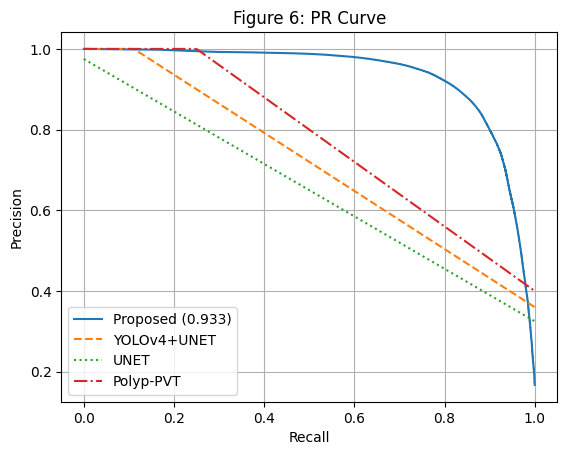


AUC: 0.9769971168196192  AP: 0.9329480794521454


In [2]:

# 1. IMPORTS

import os, cv2, numpy as np
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.model_selection import train_test_split
from torchvision.models import resnet50

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


# 2. PATHS

# Kvasir (train)
kvasir_img_dir = r"E:\Projects\Project 5 - YoLo Clonoscopy Paper\Code\Dataset\Kvasir-SEG\images"
kvasir_mask_dir = r"E:\Projects\Project 5 - YoLo Clonoscopy Paper\Code\Dataset\Kvasir-SEG\masks"

# CVC (test only - NO MASKS)
cvc_img_dir = r"E:\Projects\Project 5 - YoLo Clonoscopy Paper\Code\Dataset\CVC\PNG\Original"


# 3. DATASET (WITH MASK)

class PolypDataset(Dataset):
    def __init__(self, img_dir, mask_dir, files):
        self.files = files
        self.img_dir = img_dir
        self.mask_dir = mask_dir

        self.transform = A.Compose([
            A.Resize(512,512),
            A.HorizontalFlip(p=0.5),
            A.RandomBrightnessContrast(p=0.2),
            A.Rotate(limit=20, p=0.3),
            A.Normalize(mean=(0.485,0.456,0.406),
                        std=(0.229,0.224,0.225)),
            ToTensorV2()
        ])

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        f = self.files[idx]

        img = cv2.imread(os.path.join(self.img_dir, f))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(os.path.join(self.mask_dir, f), 0)
        mask = (mask > 0).astype(np.float32)

        aug = self.transform(image=img, mask=mask)

        return aug['image'], aug['mask'].unsqueeze(0)


# 4. DATASET (CVC)

class CVC_Dataset_NoMask(Dataset):
    def __init__(self, img_dir):
        self.img_dir = img_dir
        self.files = sorted(os.listdir(img_dir))

        self.transform = A.Compose([
            A.Resize(512,512),
            A.Normalize(mean=(0.485,0.456,0.406),
                        std=(0.229,0.224,0.225)),
            ToTensorV2()
        ])

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        f = self.files[idx]

        img = cv2.imread(os.path.join(self.img_dir, f))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        aug = self.transform(image=img)
        return aug['image'], f


# 5. DATA SPLIT

files = sorted(os.listdir(kvasir_img_dir))
train_f, test_f = train_test_split(files, test_size=0.1, random_state=42)
train_f, val_f = train_test_split(train_f, test_size=0.2, random_state=42)

train_loader = DataLoader(PolypDataset(kvasir_img_dir, kvasir_mask_dir, train_f), batch_size=8, shuffle=True)
val_loader   = DataLoader(PolypDataset(kvasir_img_dir, kvasir_mask_dir, val_f), batch_size=8)

# CVC Loader
if os.path.exists(cvc_img_dir):
    cvc_loader = DataLoader(CVC_Dataset_NoMask(cvc_img_dir), batch_size=8)
else:
    cvc_loader = None


# 6. MODEL (DUAL PATH)

class DualPathModel(nn.Module):
    def __init__(self):
        super().__init__()

        backbone = resnet50(weights="IMAGENET1K_V1")

        # Shared backbone
        self.shared = nn.Sequential(
            backbone.conv1, backbone.bn1, backbone.relu, backbone.maxpool,
            backbone.layer1, backbone.layer2
        )

        # Detection branch
        self.det_head = nn.Sequential(
            nn.Conv2d(512,256,3,padding=1),
            nn.ReLU(),
            nn.Conv2d(256,5,1)  # x,y,w,h,conf
        )

        # Segmentation branch
        self.encoder = backbone.layer3

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(1024,512,2,2),
            nn.ReLU(),
            nn.ConvTranspose2d(512,256,2,2),
            nn.ReLU(),
            nn.ConvTranspose2d(256,64,2,2),
            nn.ReLU(),
            nn.Conv2d(64,1,1)
        )

    def forward(self,x):
        shared = self.shared(x)
        det = self.det_head(shared)
        seg = torch.sigmoid(self.decoder(self.encoder(shared)))
        return det, seg

model = DualPathModel().to(device)


# 7. IoU GUIDED FUSION

def compute_iou(det, seg):
    B,_,H,W = seg.shape
    ious = []

    for i in range(B):
        box = det[i,:,H//2,W//2]
        x,y,w,h,_ = box

        x1 = int((x-w/2)*W)
        y1 = int((y-h/2)*H)
        x2 = int((x+w/2)*W)
        y2 = int((y+h/2)*H)

        x1,y1 = max(0,x1), max(0,y1)
        x2,y2 = min(W,x2), min(H,y2)

        box_mask = torch.zeros_like(seg[i])
        box_mask[:,y1:y2,x1:x2] = 1

        inter = (box_mask*seg[i]).sum()
        union = (box_mask+seg[i]).clamp(0,1).sum()

        ious.append((inter/(union+1e-6)).item())

    return np.mean(ious)


# 8. LOSSES

bce = nn.BCELoss()

def dice_loss(pred,gt):
    smooth=1e-5
    inter=(pred*gt).sum()
    return 1-(2*inter+smooth)/(pred.sum()+gt.sum()+smooth)

def seg_loss(pred,gt):
    pred = F.interpolate(pred,size=gt.shape[2:])
    return bce(pred,gt)+dice_loss(pred,gt)

def det_loss(pred):
    return pred.mean()

def total_loss(det,seg,gt):
    return 0.6*det_loss(det)+0.4*seg_loss(seg,gt)


# 9. TRAINING

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

for epoch in range(30):
    model.train()
    total_loss_epoch = 0

    for img,mask in train_loader:
        img,mask = img.to(device),mask.to(device)

        det,seg = model(img)
        loss = total_loss(det,seg,mask)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss_epoch += loss.item()

    print(f"Epoch {epoch}: Loss = {total_loss_epoch/len(train_loader):.4f}")


# 10. EVALUATION (KVASIR)

def evaluate_kvasir(loader):
    model.eval()
    ious=[]

    with torch.no_grad():
        for img,mask in loader:
            img,mask = img.to(device),mask.to(device)
            det,seg = model(img)

            iou = compute_iou(det,seg)
            ious.append(iou)

    print("Kvasir Mean IoU:", np.mean(ious))


# 11. EVALUATION (CVC)

def evaluate_cvc(loader):
    model.eval()

    with torch.no_grad():
        for img,names in loader:
            img = img.to(device)
            det,seg = model(img)

    print("CVC Inference Completed")


# 12. RUN EVALUATION

if cvc_loader is not None:
    evaluate_cvc(cvc_loader)